In [2]:
import tensorflow as tf
tf.__version__

'2.19.0'

In [49]:
from tensorflow.keras.datasets.mnist import load_data
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [50]:
(X_train , y_train),(X_test, y_test) = load_data()

In [51]:
X_train.shape , X_test.shape , y_train.shape , y_test.shape

((60000, 28, 28), (10000, 28, 28), (60000,), (10000,))

In [52]:
set(y_train)   #displays unique values

{np.uint8(0),
 np.uint8(1),
 np.uint8(2),
 np.uint8(3),
 np.uint8(4),
 np.uint8(5),
 np.uint8(6),
 np.uint8(7),
 np.uint8(8),
 np.uint8(9)}

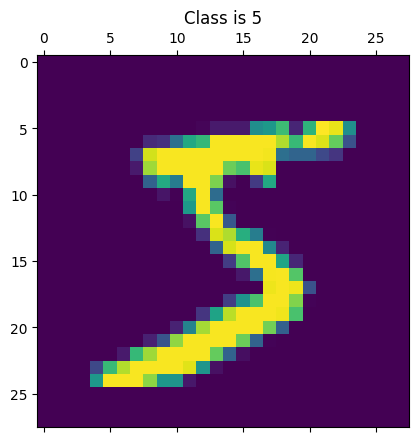

In [10]:
# Visualization
import matplotlib.pyplot as plt
plt.matshow (X_train[0])
plt.title(f"Class is {y_train[0]}")
plt.show()

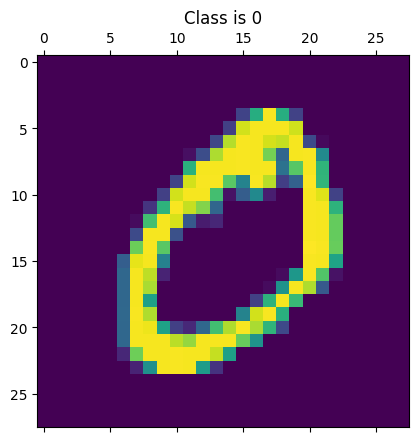

In [11]:
plt.matshow (X_train[1])
plt.title(f"Class is {y_train[1]}")
plt.show()

In [53]:
# PreProcessing
# Image is interpreted in the format of pixel intensities (0 to 255)
import numpy as np
np.max(X_train), np.min(X_train)

(np.uint8(255), np.uint8(0))

In [54]:
# Normalize the image pixel values so range is 0 to 1
X_train = X_train / 255.0
X_test = X_test / 255.0

In [55]:
np.max(X_train), np.min(X_train)

(np.float64(1.0), np.float64(0.0))

In [56]:
np.max(X_test), np.min(X_test)

(np.float64(1.0), np.float64(0.0))

In [57]:
# Flattening --> converting the multi dimension feature to 1 dimension
X_train = X_train.reshape(60000,784)       #28*28 = 784
X_test = X_test.reshape(10000,784)

In [58]:
#Target --> One hot reperesentation
y_train = tf.keras.utils.to_categorical(y_train)
y_test = tf.keras.utils.to_categorical(y_test)

In [59]:
y_train[:5]

array([[0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [60]:
#Model
model = Sequential()
model.add(Dense(256, activation = 'relu', input_shape =[784,], name='h1'))
model.add(Dense(128, activation = 'relu', name='h2'))
model.add(Dense(10, activation = 'softmax', name='o'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ h1 (Dense)                      │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ h2 (Dense)                      │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ o (Dense)                       │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [61]:
model.layers[0]. get_weights() #returns both weights and bias

[array([[ 0.05987376, -0.00172137,  0.01289932, ...,  0.05599137,
          0.03043561,  0.04074962],
        [ 0.01355967,  0.01999546, -0.01976084, ..., -0.03914169,
          0.0706667 ,  0.03614627],
        [-0.0573973 , -0.06963737, -0.00874357, ..., -0.04137885,
          0.02877694,  0.06214198],
        ...,
        [-0.06872262, -0.06383714, -0.04653741, ..., -0.06828503,
          0.05003907, -0.06042514],
        [ 0.04787692,  0.00594119,  0.04369407, ...,  0.07524161,
          0.03478562, -0.00797592],
        [-0.03812215, -0.0315764 ,  0.04327092, ..., -0.04372339,
         -0.05734398,  0.02938839]], dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

In [62]:
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [63]:
history = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=25,
    validation_data=(X_test, y_test)
)

Epoch 1/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.9008 - loss: 0.3359 - val_accuracy: 0.9682 - val_loss: 0.1011
Epoch 2/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9722 - loss: 0.0915 - val_accuracy: 0.9732 - val_loss: 0.0916
Epoch 3/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9799 - loss: 0.0675 - val_accuracy: 0.9762 - val_loss: 0.0931
Epoch 4/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9855 - loss: 0.0493 - val_accuracy: 0.9783 - val_loss: 0.0897
Epoch 5/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9884 - loss: 0.0394 - val_accuracy: 0.9820 - val_loss: 0.0799
Epoch 6/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9900 - loss: 0.0328 - val_accuracy: 0.9771 - val_loss: 0.1015
Epoch 7/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9923 - loss: 0.0264 - val_accuracy: 0.9807 - val_loss: 0.0909
Epoch 8/25
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9938 - loss: 0

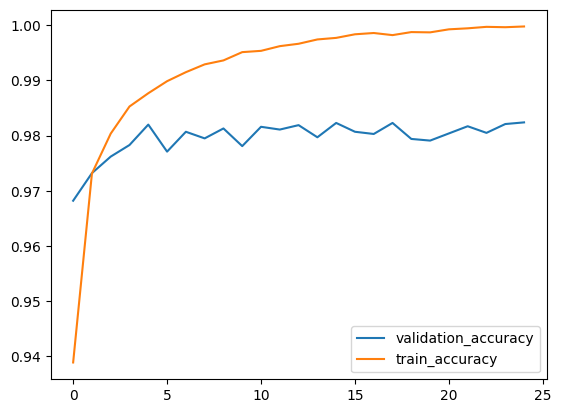

In [67]:
h = history.history
plt.plot(h['val_accuracy'], label = 'validation_accuracy')
plt.plot(h['accuracy'], label = 'train_accuracy')
plt.legend()
plt.show()

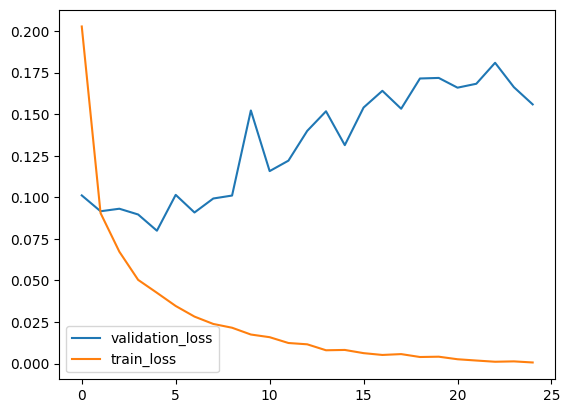

In [69]:
plt.plot(h['val_loss'], label = 'validation_loss')
plt.plot(h['loss'], label = 'train_loss')
plt.legend()
plt.show()
#OVERFITTING

In [70]:
model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9806 - loss: 0.1855


[0.15584978461265564, 0.9824000000953674]